In [ ]:
# %%
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.decomposition import PCA, IncrementalPCA

import torch
from tools.oja_pca import OjaPCA

import online_svd_buffer as op  # your module (contains all the numba helpers, globals, etc.)

In [ ]:
DATA_DIR = "npy_chunks"
FILE_PATTERN = "X_{:04d}.npy"
NUM_FILES = 10
HOLDOUT_FILE = 0

# model params
P = 15
G = 500

# streaming batch sizes
ONLINE_BATCH = 3000   
IPCA_BATCH   = 3000
OJA_BATCH    = 3000

# monitor set (for traces)
MONITOR_ROWS = 2000
EVAL_EVERY = 1  # evaluate EVR every k updates (increase to speed up)

np.set_printoptions(suppress=True, precision=4, linewidth=200)

In [3]:
def iter_chunks(include_holdout=False):
    for i in range(NUM_FILES):
        if not include_holdout and i == HOLDOUT_FILE:
            continue
        path = os.path.join(DATA_DIR, FILE_PATTERN.format(i))
        yield np.load(path)  # (N, d)

first_train = np.load(os.path.join(DATA_DIR, FILE_PATTERN.format(0)))
N0, d = first_train.shape
TOTAL_SAMPLES = (NUM_FILES - 1) * N0

holdout = np.load(os.path.join(DATA_DIR, FILE_PATTERN.format(HOLDOUT_FILE)))
monitor = holdout[:MONITOR_ROWS].T.astype(np.float32, copy=False)  # (d, m)

print("Train chunk shape:", first_train.shape)
print("Holdout chunk shape:", holdout.shape)
print("d =", d)
print("Monitor shape:", monitor.shape)
print("Training samples:", TOTAL_SAMPLES)

Train chunk shape: (50000, 1536)
Holdout chunk shape: (50000, 1536)
d = 1536
Monitor shape: (1536, 2000)
Training samples: 450000


In [4]:
def evr_from_recon(X_true, X_recon):
    err = np.linalg.norm(X_true - X_recon, "fro")**2
    tot = np.linalg.norm(X_true, "fro")**2
    return 1.0 - err / tot

def evr_from_U(X_mon, U, p):
    # X_mon: (d, m)
    Z = U[:, :p].T @ X_mon
    X_rec = U[:, :p] @ Z
    return evr_from_recon(X_mon, X_rec)

In [5]:
def load_all_as_X_float32():
    blocks = []
    for chunk in tqdm(iter_chunks(), total=NUM_FILES - 1, desc="Loading chunks"):
        blocks.append(chunk.astype(np.float32, copy=False).T)  # (d, N)
    return np.hstack(blocks)  # (d, totalN)

X = load_all_as_X_float32()
print("X:", X.shape, X.dtype)

Loading chunks: 100%|██████████| 9/9 [00:00<00:00, 10.64it/s]


X: (1536, 419964) float32


In [ ]:
def fit_safe(x, p, n_iter, u, scores, row_topk_vals, row_topk_idx, TEMP_COL):
    """
    A minimally modified version of your op.fit that:
      - never indexes x[jq, jq] when jq is out of bounds
      - reselects a new (iq, jq) if an invalid jq appears
    """
    d_local = x.shape[0]
    n_active = x.shape[1]

    # compute initial scores/topk for current x
    op.compute_and_assign_topk_cf(p, x, scores, row_topk_vals, row_topk_idx)

    for _ in range(n_iter):
        iq, jq = op.get_max_topk(row_topk_vals, row_topk_idx)

        # If no valid pivot remains, stop early
        if iq == -1 or jq == -1:
            break

        # Safety: jq must be in the active width
        # If not, invalidate this candidate and reselect
        guard = 0
        while jq >= n_active:
            row_topk_vals[iq, 0] = op.NEG_INF32
            row_topk_idx[iq, 0] = -1
            iq, jq = op.get_max_topk(row_topk_vals, row_topk_idx)
            if iq == -1 or jq == -1:
                return u, x
            guard += 1
            if guard > 10000:
                raise RuntimeError("Too many invalid pivot reselections; check score bookkeeping.")

        # Now safe to access x[jq, jq] if jq < d_local; if jq >= d_local treat as 0 like you do
        if jq >= d_local:
            xji = 0.0
            xjj = 0.0
        else:
            xji = x[jq, iq]
            xjj = x[jq, jq]

        t = np.zeros((2, 2), dtype=np.float64)
        t[0, 0] = x[iq, iq]
        t[0, 1] = x[iq, jq]
        t[1, 0] = xji
        t[1, 1] = xjj

        G, _, H = np.linalg.svd(t)

        # update intermediate x and u using your existing updater
        # IMPORTANT: op.mul_update_numba currently calls get_new_topk_numba2 with "n" passed in.
        # This is OK as long as scores tail is NEG_INF (so it can’t win), and we never write beyond active.
        op.mul_update_numba(x, iq, jq, H, G, u, d_local, n_active, p, scores, row_topk_vals, row_topk_idx, TEMP_COL)

    return u, x


def fit_batched_traced(trueX, p, n_iter, batch_size=300, monitor=None, eval_every=1):
    """
    Streaming wrapper around your method that:
      - runs batches exactly like op.fit_batched
      - records real per-batch EVR on `monitor` (if provided)
    """
    op.set_num_threads(op.NUMBA_THREADS)

    d_local = trueX.shape[0]
    n_total = trueX.shape[1]

    if batch_size < d_local:
        print(f"Batch size too small! Setting to {d_local}")
        batch_size = d_local

    # init global buffers used by fast matmuls
    op._init_global_buf(d_local, batch_size + p, np.float64)

    total_batches = n_total // batch_size + (1 if n_total % batch_size else 0)
    print("Total batches:", total_batches)

    # first batch
    start_index = 0
    end_index = min(batch_size, n_total)
    x = trueX[:, start_index:end_index]
    x_batch = np.array(x, copy=True).astype(np.float64, copy=False)

    u = np.identity(d_local, dtype=np.float64)

    # IMPORTANT: scores sized to full n_total, but filled with NEG_INF32 so tail never wins
    scores = np.empty((p, n_total), dtype=np.float64)
    scores.fill(op.NEG_INF32)

    row_topk_vals = np.empty((p, op.TOP_K_SCORES), dtype=np.float64)
    row_topk_vals.fill(op.NEG_INF32)
    row_topk_idx = np.empty((p, op.TOP_K_SCORES), dtype=np.int64)
    row_topk_idx.fill(-1)

    traces = np.zeros(total_batches, dtype=np.float64)
    samples_seen = np.zeros(total_batches, dtype=np.int64)

    for bi in tqdm(range(total_batches), desc="OnlinePCA batches"):
        n_active = x_batch.shape[1]

        # Reset only the ACTIVE part of scores; tail stays NEG_INF
        scores[:, :n_active].fill(op.NEG_INF32)
        row_topk_vals.fill(op.NEG_INF32)
        row_topk_idx.fill(-1)

        u, x = fit_safe(x_batch, p, n_iter, u, scores, row_topk_vals, row_topk_idx, op.TEMP_COL)

        # Trace on monitor (not timed)
        if monitor is not None and (bi % eval_every == 0):
            traces[bi] = evr_from_U(monitor.astype(np.float64, copy=False), u, p)
        elif monitor is not None and bi > 0:
            traces[bi] = traces[bi - 1]  # hold last
        else:
            traces[bi] = 0.0

        samples_seen[bi] = min((bi + 1) * batch_size, n_total)

        if end_index == n_total:
            # trim to actual used length
            traces = traces[:bi+1]
            samples_seen = samples_seen[:bi+1]
            break

        # prepare next batch
        start_index += batch_size
        end_index = min(end_index + batch_size, n_total)

        x_batch = np.hstack((
            x[:, :p],
            u.T @ trueX[:, start_index:end_index]
        )).astype(np.float64, copy=False)

    return traces, samples_seen, u

In [7]:
# %%
print("Warmup...")
tmp = X[:, :5000].astype(np.float64, copy=True)
_ = fit_batched_traced(tmp, p=5, n_iter=10, batch_size=max(2*d, 1536), monitor=monitor.astype(np.float64), eval_every=10)
print("Warmup done.")

Warmup...
Total batches: 2


OnlinePCA batches:   0%|          | 0/2 [00:00<?, ?it/s]d:\master-AI\online PCA\online-pca\online_svd_buffer.py:249: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "online_svd_buffer.py", line 104:
@njit(parallel=True)
def compute_score_nf_numba(i, j, x, d):
^

  val = compute_score_nf_numba(iq, s, x, d)[2]
d:\master-AI\online PCA\online-pca\online_svd_buffer.py:315: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "online_svd_buffer.py", line 104:
@njit(parallel=True)
def compute_score_nf_numba(i, j, x, d):
^

  val = compute_s

Warmup done.


In [8]:
# %%
print("Running OnlinePCA (time + samples tracked)...")

online_tr = []
online_time_axis = []
online_samples = []

t_start = time.perf_counter()

d_local = X.shape[0]
batch_size = max(ONLINE_BATCH, d_local)

start_index = 0
end_index = min(batch_size, X.shape[1])

x = X[:, start_index:end_index]
x_batch = np.array(x, copy=True).astype(np.float64)
u = np.identity(d_local)

scores = np.empty((P, X.shape[1]), dtype=np.float64)
scores.fill(op.NEG_INF32)

row_topk_vals = np.empty((P, op.TOP_K_SCORES), dtype=np.float64)
row_topk_vals.fill(op.NEG_INF32)
row_topk_idx = np.empty((P, op.TOP_K_SCORES), dtype=np.int64)
row_topk_idx.fill(-1)

samples_seen = 0

total_batches = X.shape[1] // batch_size + (1 if X.shape[1] % batch_size else 0)

for bi in tqdm(range(total_batches), desc="OnlinePCA batches"):

    t0 = time.perf_counter()
    u, x = fit_safe(x_batch, P, G, u, scores, row_topk_vals, row_topk_idx, op.TEMP_COL)
    t1 = time.perf_counter()

    samples_seen += (end_index - start_index)

    online_time_axis.append(t1 - t_start)
    online_samples.append(samples_seen)

    # EVR (not timed)
    evr_val = evr_from_U(monitor.astype(np.float64), u, P)
    online_tr.append(evr_val)

    if end_index == X.shape[1]:
        break

    start_index += batch_size
    end_index = min(end_index + batch_size, X.shape[1])

    x_batch = np.hstack((
        x[:, :P],
        u.T @ X[:, start_index:end_index]
    )).astype(np.float64)

online_time_axis = np.array(online_time_axis)
online_samples = np.array(online_samples)
online_tr = np.array(online_tr)

print("OnlinePCA done.")

Running OnlinePCA (time + samples tracked)...


OnlinePCA batches:  99%|█████████▉| 139/140 [00:35<00:00,  3.93it/s]

OnlinePCA done.


In [9]:
# %%
print("Running IncrementalPCA (time-tracked + samples)...")

ipca = IncrementalPCA(n_components=P, batch_size=IPCA_BATCH)

ipca_tr = []
ipca_time_axis = []
ipca_samples = []

fit_time_accum = 0.0
samples_seen = 0

for chunk in tqdm(iter_chunks(), total=NUM_FILES, desc="IPCA chunks"):
    chunk = chunk.astype(np.float32, copy=False)
    N = chunk.shape[0]

    for start in range(0, N, IPCA_BATCH):
        batch = chunk[start:start+IPCA_BATCH]

        t0 = time.perf_counter()
        ipca.partial_fit(batch)
        t1 = time.perf_counter()
        fit_time_accum += (t1 - t0)

        samples_seen += batch.shape[0]

        ipca_time_axis.append(fit_time_accum)
        ipca_samples.append(samples_seen)

        # EVR (not counted)
        Z = ipca.transform(monitor.T)
        mon_rec = ipca.inverse_transform(Z).T
        ipca_tr.append(evr_from_recon(monitor, mon_rec))

ipca_time_axis = np.array(ipca_time_axis)
ipca_samples = np.array(ipca_samples)
ipca_tr = np.array(ipca_tr)

print("IncrementalPCA done.")

Running IncrementalPCA (time-tracked + samples)...


IPCA chunks:  90%|█████████ | 9/10 [03:07<00:20, 20.88s/it]

IncrementalPCA done.


In [10]:
print("Running OjaPCA (time + samples tracked)...")

oja = OjaPCA(n_features=d, n_components=P, eta=0.005)
X_mon_t = torch.tensor(monitor.T, dtype=torch.float32)

oja_tr = []
oja_time_axis = []
oja_samples = []

fit_time_accum = 0.0
samples_seen = 0

for chunk in tqdm(iter_chunks(), total=NUM_FILES, desc="Oja chunks"):
    chunk = chunk.astype(np.float32, copy=False)
    N = chunk.shape[0]

    for start in range(0, N, OJA_BATCH):
        batch_np = chunk[start:start+OJA_BATCH]
        batch_t = torch.tensor(batch_np, dtype=torch.float32)

        t0 = time.perf_counter()
        if hasattr(oja, "forward"):
            oja(batch_t)
        else:
            oja.partial_fit(batch_t)
        t1 = time.perf_counter()

        fit_time_accum += (t1 - t0)
        samples_seen += batch_np.shape[0]

        oja_time_axis.append(fit_time_accum)
        oja_samples.append(samples_seen)

        # EVR (not timed)
        with torch.no_grad():
            Z = oja.transform(X_mon_t)
            X_rec = oja.inverse_transform(Z)

        oja_tr.append(evr_from_recon(monitor, np.array(X_rec).T))

oja_time_axis = np.array(oja_time_axis)
oja_samples = np.array(oja_samples)
oja_tr = np.array(oja_tr)

print("OjaPCA done.")

Running OjaPCA (time + samples tracked)...


Oja chunks:   0%|          | 0/10 [00:00<?, ?it/s]C:\Users\Radu Filipescu\AppData\Local\Temp\ipykernel_19492\1171435867.py:39: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  oja_tr.append(evr_from_recon(monitor, np.array(X_rec).T))
Oja chunks:  90%|█████████ | 9/10 [00:02<00:00,  3.57it/s]

OjaPCA done.


In [11]:
print("Running FSM (time + samples tracked)...")

fsm = FSM(P, d)

fsm_tr = []
fsm_time_axis = []
fsm_samples = []

fit_time_accum = 0.0
samples_seen = 0

for chunk in tqdm(iter_chunks(), total=NUM_FILES, desc="FSM chunks"):
    chunk = chunk.astype(np.float64, copy=False)

    for start in range(0, chunk.shape[0], OJA_BATCH):
        batch = chunk[start:start+OJA_BATCH]

        t0 = time.perf_counter()
        for x_i in batch:
            fsm.fit_next(x_i)
        t1 = time.perf_counter()

        fit_time_accum += (t1 - t0)
        samples_seen += batch.shape[0]

        fsm_time_axis.append(fit_time_accum)
        fsm_samples.append(samples_seen)

        # EVR on monitor (not timed)
        U_fsm = np.asarray(fsm.get_components())

        # normalize shape to (d, P)
        if U_fsm.shape == (P, d):
            U_fsm = U_fsm.T
        elif U_fsm.shape != (d, P):
            raise ValueError(f"Unexpected FSM component shape: {U_fsm.shape}")

        fsm_tr.append(evr_from_U(monitor.astype(np.float64, copy=False), U_fsm, P))

fsm_time_axis = np.array(fsm_time_axis)
fsm_samples = np.array(fsm_samples)
fsm_tr = np.array(fsm_tr)

print("FSM done.")

Running FSM (time + samples tracked)...


FSM chunks:  90%|█████████ | 9/10 [00:22<00:02,  2.54s/it]

FSM done.


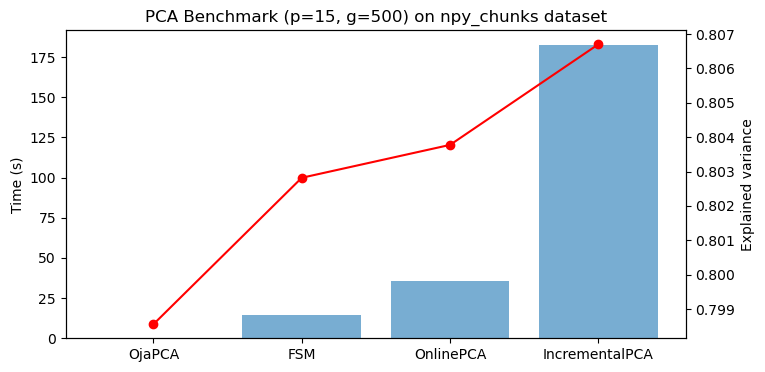

In [12]:
results = [
    {
        "method": "IncrementalPCA",
        "time": ipca_time_axis[-1],
        "explained_variance": ipca_tr[-1],
    },
    {
        "method": "OjaPCA",
        "time": oja_time_axis[-1],
        "explained_variance": oja_tr[-1],
    },
    {
        "method": "FSM",
        "time": fsm_time_axis[-1],
        "explained_variance": fsm_tr[-1],
    },
    {
        "method": "OnlinePCA",
        "time": online_time_axis[-1],
        "explained_variance": online_tr[-1],
    },
]

results.sort(key=lambda r: r["time"])

methods = [r["method"] for r in results]
times = [r["time"] for r in results]
evrs = [r["explained_variance"] for r in results]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.bar(methods, times, alpha=0.6)
ax2.plot(methods, evrs, "o-", color="red")

ax1.set_ylabel("Time (s)")
ax2.set_ylabel("Explained variance")

plt.title(f"PCA Benchmark (p={P}, g={G}) on npy_chunks dataset")
plt.show()

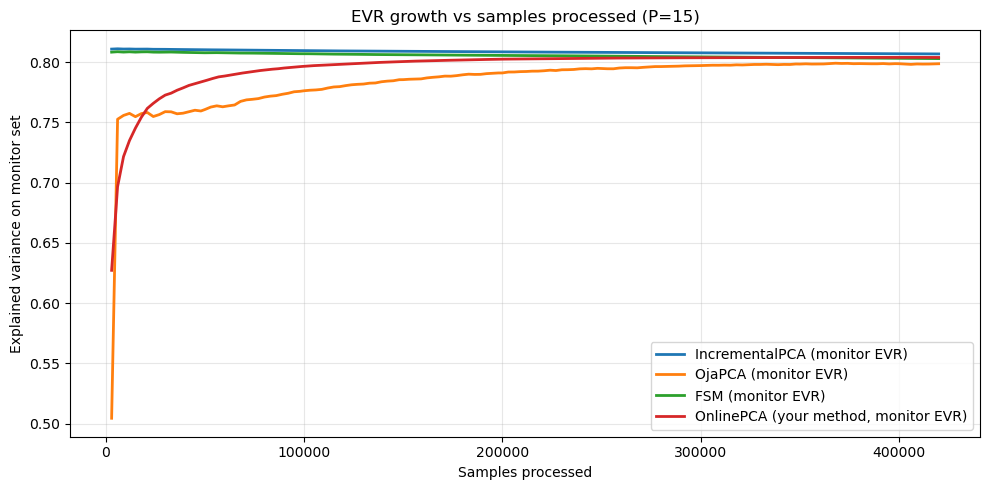

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(ipca_samples, ipca_tr, lw=2, label="IncrementalPCA (monitor EVR)")
plt.plot(oja_samples,  oja_tr,  lw=2, label="OjaPCA (monitor EVR)")
plt.plot(fsm_samples,  fsm_tr,  lw=2, label="FSM (monitor EVR)")
plt.plot(online_samples, online_tr, lw=2, label="OnlinePCA (your method, monitor EVR)")

plt.xlabel("Samples processed")
plt.ylabel("Explained variance on monitor set")
plt.title(f"EVR growth vs samples processed (P={P})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

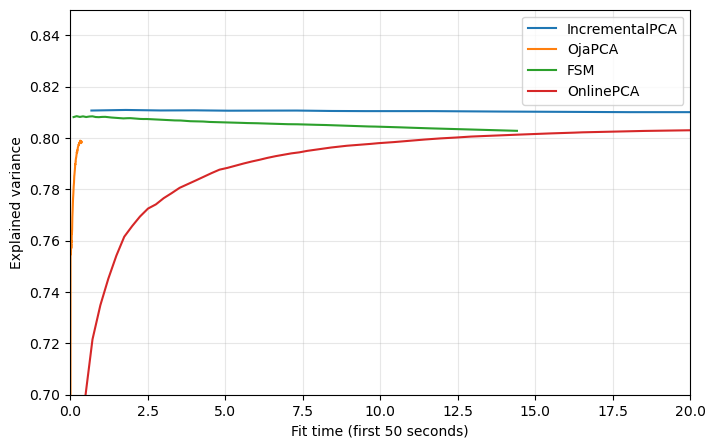

In [17]:
plt.figure(figsize=(8,5))
plt.plot(ipca_time_axis, ipca_tr, label="IncrementalPCA")
plt.plot(oja_time_axis, oja_tr, label="OjaPCA")
plt.plot(fsm_time_axis, fsm_tr, label="FSM")
plt.plot(online_time_axis, online_tr, label="OnlinePCA")
plt.xlabel("Fit time (first 50 seconds)")
plt.ylabel("Explained variance")
plt.xlim(0, 20)
plt.ylim(0.7, 0.85)
plt.legend()
plt.grid(alpha=0.3)
plt.show()